# MongoDB provisioning — smoke analysis

Post-hoc analysis of the 5-method × 3-harness smoke after packing the
HTML-robust, nested-message scorers.

- Experiment: `mongodb-provisioning`
- Run request: `01M0JXAKCYW7WGSN5S4SV28H0H`
- Matrix: 5 prompts × Codex/Terra, Claude/Sonnet, Cursor/Grok 4.5 × n=2 (30 trials)
- Date: 2026-08-21
- Prompts: `docker`, `atlas-ephemeral-curl`, `atlas-cli-local`,
  `local-package-manager`, `atlas-cli-cloud`
- Skipped: `atlas-ephemeral-naive`, `codex-luna`, `cursor-sonnet`, `cursor-terra`

A trial **passes** only when all three tests pass: `uri-reported`,
`connection-verified-in-agent`, and `method-constraint`. For docker / Atlas CLI
local / apt, method-constraint is a documented no-op. For Atlas cloud and
ephemeral-curl it requires `*.mongodb.net` / `*.mongodb-dev.net`.

This notebook queries AX with `ax experiment query <id> sql` (ClickHouse SQL →
NDJSON → pandas). Queries return derived metrics and boolean evidence, not raw
URIs or tool payloads, so generated credentials stay out of the notebook output.


Install analysis dependencies into the active kernel (the project `.venv` if that is selected). Then re-run the next cell.

`ax auth status` should show a signed-in org. Offline alternative: `ax run download 01M0JXAKCYW7WGSN5S4SV28H0H`, then set `AX_PARQUET_DIR` to the resulting `.axp/downloads/<id>/` directory.


In [ ]:
%pip install requests pandas matplotlib numpy python-dotenv


Note: you may need to restart the kernel to use updated packages.


In [ ]:
from __future__ import annotations

import json
import os
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display

EXPERIMENT_ID = "mongodb-provisioning"
RUN_REQUEST_ID = "01M0JXAKCYW7WGSN5S4SV28H0H"
AX_API_BASE = os.environ.get("AX_API_BASE", "https://app.514.ax").rstrip("/")
AX_PARQUET_DIR = os.environ.get("AX_PARQUET_DIR", "")
CLI_CREDENTIALS_PATH = Path.home() / ".fiveonefour/axp/credentials.toml"
EXPECTED_TRIALS = 30
TEST_NAMES = [
    "uri-reported",
    "connection-verified-in-agent",
    "method-constraint",
]
UNAUTH_METHODS = [
    "docker",
    "atlas-ephemeral-curl",
    "atlas-cli-local",
    "local-package-manager",
]
CLOUD_BOUND = ["atlas-ephemeral-curl", "atlas-cli-cloud"]

METHOD_ORDER = [
    "docker",
    "atlas-ephemeral-curl",
    "atlas-cli-local",
    "local-package-manager",
    "atlas-cli-cloud",
]
AGENT_ORDER = ["codex", "claude", "cursor"]
DISPLAY_NAMES = {
    "docker": "Docker",
    "atlas-ephemeral-curl": "Ephemeral + curl",
    "atlas-cli-local": "Atlas CLI local",
    "local-package-manager": "apt / packages",
    "atlas-cli-cloud": "Atlas CLI cloud",
    "codex": "Codex + Terra",
    "claude": "Claude + Sonnet",
    "cursor": "Cursor + Grok 4.5",
}
COLORS = {
    "docker": "#00A35C",
    "atlas-ephemeral-curl": "#0EA5E9",
    "atlas-cli-local": "#2563EB",
    "local-package-manager": "#8C8C8C",
    "atlas-cli-cloud": "#DC2626",
    "codex": "#111827",
    "claude": "#D97706",
    "cursor": "#7C3AED",
}

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)


def _load_dotenv() -> None:
    try:
        from dotenv import load_dotenv
    except ImportError:
        return
    here = Path.cwd().resolve()
    for directory in [here, *here.parents]:
        env_file = directory / ".env"
        if env_file.is_file():
            load_dotenv(env_file)
            return


def _credentials_from_cli_store() -> dict[str, str]:
    """Read key names from the AX CLI store. Never print values."""
    if not CLI_CREDENTIALS_PATH.is_file():
        return {}
    values: dict[str, str] = {}
    for line in CLI_CREDENTIALS_PATH.read_text().splitlines():
        stripped = line.strip()
        if not stripped or stripped.startswith("#") or stripped.startswith("["):
            continue
        if "=" not in stripped:
            continue
        key, value = stripped.split("=", 1)
        values[key.strip()] = value.strip().strip('"').strip("'")
    return values


_load_dotenv()
AX_ORG_ID = os.environ.get("AX_ORG_ID", "org_3FJv0fCt81VIGxO61n6HNbYLnHl")


def _api_key() -> str:
    key = os.environ.get("AX_API_KEY") or os.environ.get("AXP_API_KEY")
    if not key:
        key = _credentials_from_cli_store().get("api_key")
    if not key:
        raise RuntimeError(
            "No AX API key in AX_API_KEY / AXP_API_KEY, a repo .env, or "
            f"{CLI_CREDENTIALS_PATH}. Run `ax auth login` or create a token at "
            "https://app.514.ax/account/api-keys."
        )
    return key


def _parse_query_response(response: requests.Response) -> pd.DataFrame:
    text = response.text.strip()
    if not text:
        return pd.DataFrame()

    try:
        payload = response.json()
    except ValueError:
        rows = [json.loads(line) for line in text.splitlines() if line.strip()]
        return pd.DataFrame(rows)

    if isinstance(payload, list):
        return pd.DataFrame(payload)
    if isinstance(payload, dict):
        for key in ("rows", "data", "result", "results"):
            value = payload.get(key)
            if isinstance(value, list):
                return pd.DataFrame(value)
        if payload.get("sql") or payload.get("error"):
            raise RuntimeError(payload.get("error") or payload)
    raise RuntimeError(f"Unexpected AX query response shape: {type(payload).__name__}")


def ax_http_query(
    sql: str,
    *,
    experiment_id: str = EXPERIMENT_ID,
    run_id: str | None = None,
    limit: int = 10_000,
) -> pd.DataFrame:
    """Run ClickHouse SQL through the AX HTTP query API."""
    path = (
        f"/api/v1/runs/{run_id}/query"
        if run_id
        else f"/api/v1/experiments/{experiment_id}/query"
    )
    headers = {
        "Authorization": f"Bearer {_api_key()}",
        "Accept": "application/json",
        "Content-Type": "application/json",
    }
    if AX_ORG_ID:
        headers["X-Org-Id"] = AX_ORG_ID
    response = requests.post(
        f"{AX_API_BASE}{path}",
        headers=headers,
        json={"sql": sql, "limit": limit, "format": "json"},
        timeout=120,
    )
    if not response.ok:
        raise RuntimeError(
            f"AX query failed ({response.status_code}): {response.text[:500]}"
        )
    return _parse_query_response(response)


def ax_cli_query(sql: str, *, limit: int = 10_000) -> pd.DataFrame:
    """Run ClickHouse SQL through `ax experiment query <id> sql`."""
    ax = shutil.which("ax")
    if not ax:
        raise FileNotFoundError("ax CLI is not on PATH")
    command = [
        ax,
        "experiment",
        "query",
        EXPERIMENT_ID,
        "sql",
        sql,
        "--format",
        "json",
        "--limit",
        str(limit),
    ]
    if AX_ORG_ID:
        command.extend(["--org", AX_ORG_ID])
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(
            f"ax experiment query failed ({result.returncode}): {result.stderr.strip()[:500]}"
        )
    rows: list[dict] = []
    for line in result.stdout.splitlines():
        stripped = line.strip()
        if not stripped or stripped[0] not in "{[":
            continue
        try:
            parsed = json.loads(stripped)
        except json.JSONDecodeError:
            continue
        if isinstance(parsed, list):
            rows.extend(parsed)
        elif isinstance(parsed, dict):
            rows.append(parsed)
    return pd.DataFrame(rows)


def ax_parquet_query(sql: str) -> pd.DataFrame:
    """Query downloaded Parquet with DuckDB. Table names are file stems."""
    try:
        import duckdb
    except ImportError as exc:
        raise RuntimeError("Install duckdb to query AX_PARQUET_DIR.") from exc

    root = Path(AX_PARQUET_DIR).expanduser()
    files = sorted(root.rglob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files under {root}")

    con = duckdb.connect()
    for path in files:
        con.execute(
            f"CREATE OR REPLACE VIEW {path.stem} AS SELECT * FROM read_parquet(?)",
            [str(path)],
        )
    return con.execute(sql).df()


def ax_query(sql: str, **kwargs) -> pd.DataFrame:
    if AX_PARQUET_DIR:
        return ax_parquet_query(sql)
    if shutil.which("ax"):
        return ax_cli_query(sql, limit=kwargs.get("limit", 10_000))
    return ax_http_query(sql, **kwargs)


def _with_method_column(frame: pd.DataFrame) -> pd.DataFrame:
    if "method" not in frame.columns and "prompt_id" in frame.columns:
        frame = frame.rename(columns={"prompt_id": "method"})
    return frame


print(f"Experiment: {EXPERIMENT_ID}")
print(f"Run request: {RUN_REQUEST_ID}")
print(f"ax CLI: {shutil.which('ax') or 'not on PATH'}")
print(f"CLI credentials file: {'present' if CLI_CREDENTIALS_PATH.is_file() else 'missing'}")
print(
    "Query surface: "
    + (
        f"parquet {AX_PARQUET_DIR}"
        if AX_PARQUET_DIR
        else "ax experiment query CLI"
        if shutil.which("ax")
        else f"{AX_API_BASE}/api/v1/experiments/{EXPERIMENT_ID}/query"
    )
)


Matplotlib is building the font cache; this may take a moment.


Experiment: mongodb-provisioning
Run request: 01M0JXAKCYW7WGSN5S4SV28H0H
ax CLI: /opt/homebrew/bin/ax
CLI credentials file: present
Query surface: ax experiment query CLI


## Per-run metrics

Official AX `measurements` for this run request. `tool_calls_total` is the step
proxy. Completion is computed later from `test_output` (all three tests), because
`measurements.status` is not always `pass`/`fail`.


In [ ]:
per_run_sql = f"""
SELECT
    run_id,
    agent,
    model,
    prompt_id,
    repeat_idx,
    status,
    exit_reason,
    test_pass_count,
    test_fail_count,
    agent_time_ms / 1000.0 AS runtime_s,
    tool_calls_total,
    tool_calls_failed,
    input_tokens,
    output_tokens,
    cost_usd_micros / 1000000.0 AS cost_usd
FROM measurements
WHERE run_request_id = '{RUN_REQUEST_ID}'
ORDER BY agent, prompt_id, repeat_idx
"""

runs = _with_method_column(ax_query(per_run_sql))
numeric_columns = [
    "repeat_idx",
    "test_pass_count",
    "test_fail_count",
    "runtime_s",
    "tool_calls_total",
    "tool_calls_failed",
    "input_tokens",
    "output_tokens",
    "cost_usd",
]
runs[numeric_columns] = runs[numeric_columns].apply(pd.to_numeric)
runs["method"] = pd.Categorical(runs["method"], categories=METHOD_ORDER, ordered=True)
runs["agent"] = pd.Categorical(runs["agent"], categories=AGENT_ORDER, ordered=True)

print(f"Finished measurement rows: {len(runs)} (expected {EXPECTED_TRIALS} if none starved)")
print("measurements.status value counts:")
print(runs["status"].value_counts(dropna=False).to_string())
runs.head()


Finished measurement rows: 30 (expected 30 if none starved)
measurements.status value counts:
status
pass    22
fail     8


,run_id,agent,model,method,repeat_idx,status,exit_reason,test_pass_count,test_fail_count,runtime_s,tool_calls_total,tool_calls_failed,input_tokens,output_tokens,cost_usd
0,claude::anthropic-claude-sonnet-5::atlas-cli-cloud::claude-sonnet::aab6dc4422e7df7f,claude,claude-sonnet-5,atlas-cli-cloud,0,fail,end_turn,0,3,31.681,2,2,2726,1273,0.239969
1,claude::anthropic-claude-sonnet-5::atlas-cli-cloud::claude-sonnet::2d74f159e1b283e4,claude,claude-sonnet-5,atlas-cli-cloud,1,fail,end_turn,0,3,49.394,6,0,2734,2042,0.319352
2,claude::anthropic-claude-sonnet-5::atlas-cli-local::claude-sonnet::537cc08972a632c7,claude,claude-sonnet-5,atlas-cli-local,0,pass,end_turn,3,0,134.910,13,2,3038,2008,0.509462
3,claude::anthropic-claude-sonnet-5::atlas-cli-local::claude-sonnet::aa5b6213dac5e43e,claude,claude-sonnet-5,atlas-cli-local,1,pass,end_turn,3,0,114.454,17,4,3046,2819,0.511651
4,claude::anthropic-claude-sonnet-5::atlas-ephemeral-curl::claude-sonnet::79c9b60097e937e7,claude,claude-sonnet-5,atlas-ephemeral-curl,0,pass,end_turn,3,0,70.971,8,0,2883,2728,0.361222


## Official test outcomes

Boolean pass/fail per test. Failure diagnostics are truncated platform messages,
not transcript text.


In [ ]:
tests_sql = f"""
SELECT
    run_id,
    agent,
    prompt_id,
    repeat_idx,
    test_name,
    exit_code = 0 AS passed,
    exit_code,
    substring(coalesce(stderr_tail, ''), 1, 240) AS stderr_tail
FROM test_output
WHERE run_request_id = '{RUN_REQUEST_ID}'
ORDER BY agent, prompt_id, repeat_idx, test_name
"""

tests = _with_method_column(ax_query(tests_sql))
tests["repeat_idx"] = pd.to_numeric(tests["repeat_idx"])
tests["exit_code"] = pd.to_numeric(tests["exit_code"])
tests["passed"] = tests["passed"].astype(bool)
tests["method"] = pd.Categorical(tests["method"], categories=METHOD_ORDER, ordered=True)
tests["agent"] = pd.Categorical(tests["agent"], categories=AGENT_ORDER, ordered=True)

print(f"test_output rows: {len(tests)} (expected {EXPECTED_TRIALS * len(TEST_NAMES)})")
print(
    "crash signatures: "
    f"json.parse={(tests['stderr_tail'].str.contains('JSON.parse', case=False, na=False)).sum()}, "
    f"maxBuffer={(tests['stderr_tail'].str.contains('maxBuffer', case=False, na=False)).sum()}, "
    f"html={(tests['stderr_tail'].str.contains('leafygreen|<!DOCTYPE', case=False, na=False, regex=True)).sum()}, "
    f"weird_exit={(~tests['exit_code'].isin([0, 1])).sum()}"
)

test_summary = (
    tests.groupby(["agent", "method", "test_name"], observed=True)["passed"]
    .agg(passes="sum", n="count", rate="mean")
    .reset_index()
)
test_summary["rate_pct"] = test_summary["rate"] * 100
test_summary


test_output rows: 90 (expected 90)
crash signatures: json.parse=0, maxBuffer=0, html=0, weird_exit=0


,agent,method,test_name,passes,n,rate,rate_pct
0,codex,docker,connection-verified-in-agent,2,2,1.0,100.0
1,codex,docker,method-constraint,2,2,1.0,100.0
2,codex,docker,uri-reported,2,2,1.0,100.0
3,codex,atlas-ephemeral-curl,connection-verified-in-agent,0,2,0.0,0.0
4,codex,atlas-ephemeral-curl,method-constraint,2,2,1.0,100.0
5,codex,atlas-ephemeral-curl,uri-reported,2,2,1.0,100.0
6,codex,atlas-cli-local,connection-verified-in-agent,2,2,1.0,100.0
7,codex,atlas-cli-local,method-constraint,2,2,1.0,100.0
8,codex,atlas-cli-local,uri-reported,2,2,1.0,100.0
9,codex,local-package-manager,connection-verified-in-agent,2,2,1.0,100.0


In [ ]:
failures = tests.loc[~tests["passed"], ["agent", "method", "repeat_idx", "test_name", "exit_code", "stderr_tail"]]
if failures.empty:
    print("No test failures on finished runs.")
else:
    display(failures.reset_index(drop=True))


,agent,method,repeat_idx,test_name,exit_code,stderr_tail
0,claude,atlas-cli-cloud,0,connection-verified-in-agent,1,No completed mongodb connection evidence was found in agent tool calls\n
1,claude,atlas-cli-cloud,0,method-constraint,1,"Cloud-bound prompt requires an Atlas cloud URI (*.mongodb.net), not a local URI\n"
2,claude,atlas-cli-cloud,0,uri-reported,1,No MongoDB URI was found in transcript or stdout events\n
3,claude,atlas-cli-cloud,1,connection-verified-in-agent,1,No completed mongodb connection evidence was found in agent tool calls\n
4,claude,atlas-cli-cloud,1,method-constraint,1,"Cloud-bound prompt requires an Atlas cloud URI (*.mongodb.net), not a local URI\n"
5,claude,atlas-cli-cloud,1,uri-reported,1,No MongoDB URI was found in transcript or stdout events\n
6,codex,atlas-cli-cloud,0,connection-verified-in-agent,1,"Completed mongodb candidate calls were found, but no recognized successful application operation matched the codebook\n"
7,codex,atlas-cli-cloud,0,method-constraint,1,"Cloud-bound prompt requires an Atlas cloud URI (*.mongodb.net), not a local URI\n"
8,codex,atlas-cli-cloud,0,uri-reported,1,No MongoDB URI was found in transcript or stdout events\n
9,codex,atlas-cli-cloud,1,connection-verified-in-agent,1,"Completed mongodb candidate calls were found, but no recognized successful application operation matched the codebook\n"


## Summary by agent and method

Completion = all three packed tests passed. `measurements.status == 'pass'` is
shown only as a cross-check.


In [ ]:
wide = (
    tests.pivot_table(
        index="run_id",
        columns="test_name",
        values="passed",
        aggfunc="max",
        observed=True,
    )
    .reset_index()
)
for name in TEST_NAMES:
    if name not in wide.columns:
        wide[name] = False
wide["all_tests_passed"] = wide[TEST_NAMES].all(axis=1)
wide["uri_and_connection"] = wide["uri-reported"] & wide["connection-verified-in-agent"]
wide["substitution"] = (
    wide["uri_and_connection"] & ~wide["method-constraint"]
)

runs = runs.merge(
    wide[["run_id", "all_tests_passed", "uri_and_connection", "substitution", *TEST_NAMES]],
    on="run_id",
    how="left",
)
runs["all_tests_passed"] = runs["all_tests_passed"].fillna(False).astype(bool)
runs["status_pass"] = runs["status"].eq("pass")
status_mismatch = int((runs["status_pass"] != runs["all_tests_passed"]).sum())
print(f"Rows where measurements.status==pass disagrees with all-three-tests: {status_mismatch}")

summary = (
    runs.groupby(["agent", "method"], observed=True)
    .agg(
        runs=("run_id", "size"),
        all_tests_passed=("all_tests_passed", "sum"),
        pass_rate=("all_tests_passed", "mean"),
        runtime_mean_s=("runtime_s", "mean"),
        tool_calls_mean=("tool_calls_total", "mean"),
        cost_total_usd=("cost_usd", "sum"),
        cost_mean_usd=("cost_usd", "mean"),
    )
    .reset_index()
)
summary["pass_rate_pct"] = summary["pass_rate"] * 100
summary["agent_label"] = summary["agent"].map(DISPLAY_NAMES)
summary["method_label"] = summary["method"].map(DISPLAY_NAMES)

unauth = runs[runs["method"].isin(UNAUTH_METHODS)]
totals = pd.Series(
    {
        "finished_runs": len(runs),
        "all_three_tests_pass": int(runs["all_tests_passed"].sum()),
        "unauth_pass": int(unauth["all_tests_passed"].sum()),
        "unauth_n": int(len(unauth)),
        "unauth_pass_rate": float(unauth["all_tests_passed"].mean()) if len(unauth) else float("nan"),
        "atlas_cloud_pass": int(
            runs.loc[runs["method"].eq("atlas-cli-cloud"), "all_tests_passed"].sum()
        ),
        "substitution_runs": int(runs["substitution"].sum()),
        "tests_passed": int(runs["test_pass_count"].sum()),
        "tests_failed": int(runs["test_fail_count"].sum()),
        "total_cost_usd": float(runs["cost_usd"].sum()),
        "mean_cost_usd": float(runs["cost_usd"].mean()),
        "mean_runtime_s": float(runs["runtime_s"].mean()),
        "mean_tool_calls": float(runs["tool_calls_total"].mean()),
    }
)

display(totals.to_frame("value").round(3))
summary[
    [
        "agent_label",
        "method_label",
        "runs",
        "all_tests_passed",
        "pass_rate_pct",
        "runtime_mean_s",
        "tool_calls_mean",
        "cost_mean_usd",
        "cost_total_usd",
    ]
].round(3)


Rows where measurements.status==pass disagrees with all-three-tests: 0


,value
finished_runs,30.000
all_three_tests_pass,22.000
unauth_pass,22.000
unauth_n,24.000
unauth_pass_rate,0.917
atlas_cloud_pass,0.000
substitution_runs,2.000
tests_passed,74.000
tests_failed,16.000
total_cost_usd,8.349


,agent_label,method_label,runs,all_tests_passed,pass_rate_pct,runtime_mean_s,tool_calls_mean,cost_mean_usd,cost_total_usd
0,Codex + Terra,Docker,2,2,100.0,38.079,3.5,0.048,0.096
1,Codex + Terra,Ephemeral + curl,2,0,0.0,27.634,3.0,0.041,0.083
2,Codex + Terra,Atlas CLI local,2,2,100.0,119.126,14.0,0.093,0.185
3,Codex + Terra,apt / packages,2,2,100.0,79.486,8.0,0.084,0.167
4,Codex + Terra,Atlas CLI cloud,2,0,0.0,54.476,9.0,0.064,0.127
5,Claude + Sonnet,Docker,2,2,100.0,43.870,4.0,0.269,0.539
6,Claude + Sonnet,Ephemeral + curl,2,2,100.0,70.775,9.0,0.374,0.747
7,Claude + Sonnet,Atlas CLI local,2,2,100.0,124.682,15.0,0.511,1.021
8,Claude + Sonnet,apt / packages,2,2,100.0,100.136,10.0,0.473,0.945
9,Claude + Sonnet,Atlas CLI cloud,2,0,0.0,40.538,4.0,0.280,0.559


## Visualize pass rate, runtime, cost, and steps


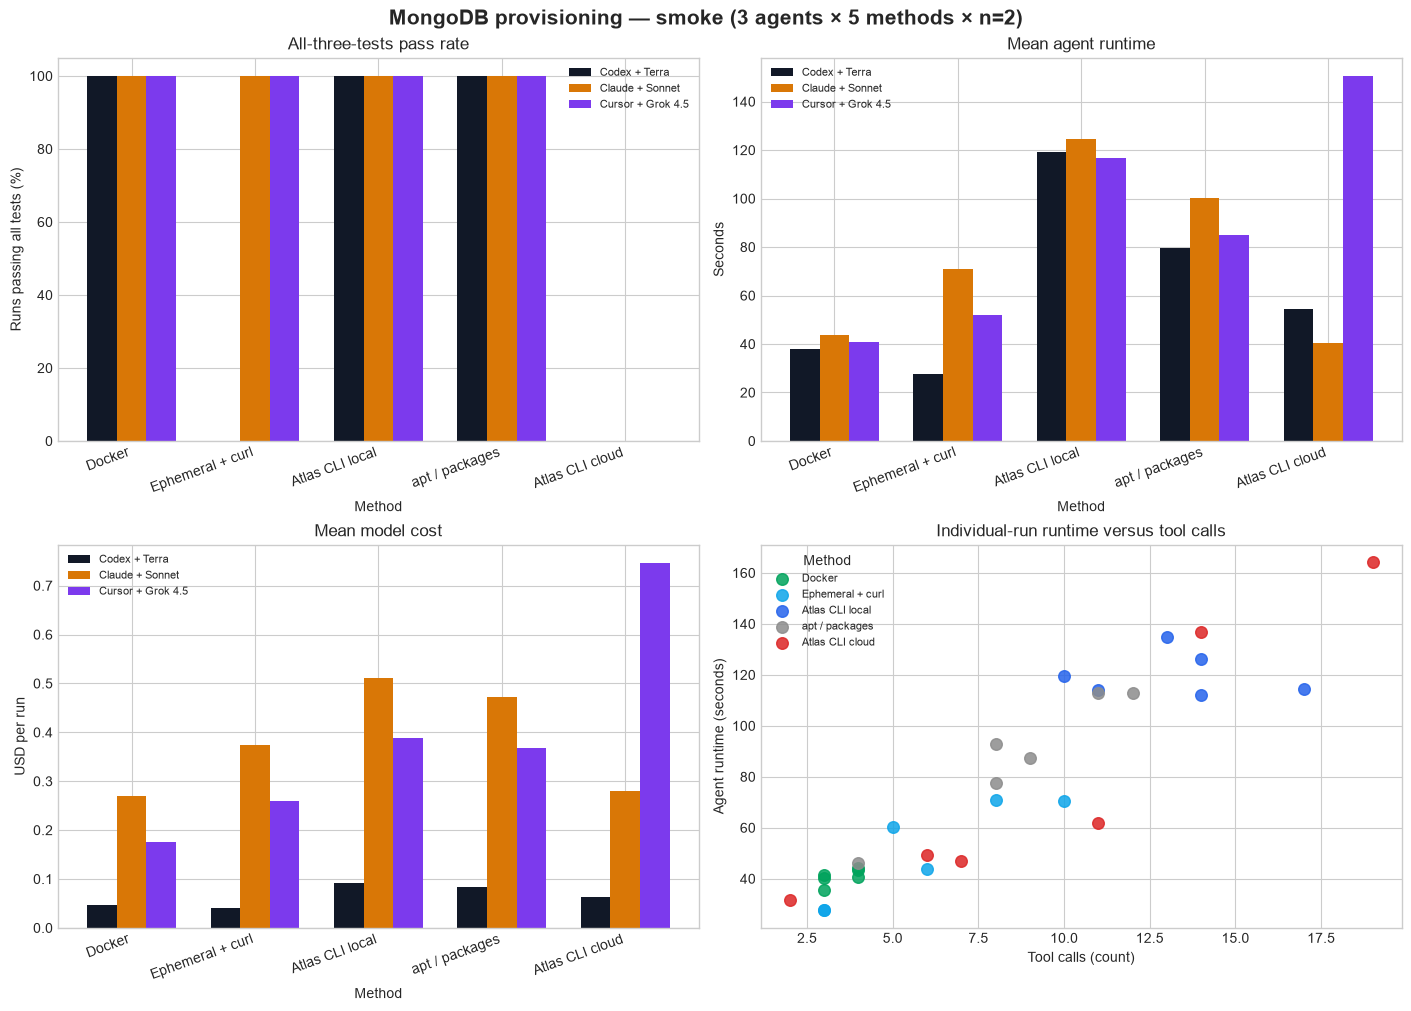

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
fig.suptitle(
    "MongoDB provisioning — smoke (3 agents × 5 methods × n=2)",
    fontsize=15,
    fontweight="bold",
)

x = np.arange(len(METHOD_ORDER))
width = 0.24


def grouped_bars(ax, column, title, ylabel, percent=False):
    for index, agent in enumerate(AGENT_ORDER):
        subset = summary[summary["agent"] == agent].set_index("method").reindex(METHOD_ORDER)
        ax.bar(
            x + (index - 1) * width,
            subset[column].fillna(0),
            width=width,
            label=DISPLAY_NAMES[agent],
            color=COLORS[agent],
        )
    ax.set_title(title)
    ax.set_xlabel("Method")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x, [DISPLAY_NAMES[name] for name in METHOD_ORDER], rotation=20, ha="right")
    if percent:
        ax.set_ylim(0, 105)
    ax.legend(frameon=False, fontsize=8)


grouped_bars(
    axes[0, 0],
    "pass_rate_pct",
    "All-three-tests pass rate",
    "Runs passing all tests (%)",
    percent=True,
)
grouped_bars(axes[0, 1], "runtime_mean_s", "Mean agent runtime", "Seconds")
grouped_bars(axes[1, 0], "cost_mean_usd", "Mean model cost", "USD per run")

for method in METHOD_ORDER:
    subset = runs[runs["method"] == method]
    axes[1, 1].scatter(
        subset["tool_calls_total"],
        subset["runtime_s"],
        label=DISPLAY_NAMES[method],
        color=COLORS[method],
        s=70,
        alpha=0.85,
    )
axes[1, 1].set_title("Individual-run runtime versus tool calls")
axes[1, 1].set_xlabel("Tool calls (count)")
axes[1, 1].set_ylabel("Agent runtime (seconds)")
axes[1, 1].legend(title="Method", frameon=False, fontsize=8)

plt.show()


## Cheat / substitution

`method-constraint` fail after uri+connection pass is the design's Atlas-cloud
substitution tail (a working local URI counted as success if we only pinged).
Tool-call booleans are payload-substring flags, not decoded credentials.


In [ ]:
cloud = runs[runs["method"].isin(CLOUD_BOUND)][
    [
        "agent",
        "method",
        "repeat_idx",
        "uri-reported",
        "connection-verified-in-agent",
        "method-constraint",
        "uri_and_connection",
        "substitution",
        "all_tests_passed",
    ]
]
display(cloud.sort_values(["method", "agent", "repeat_idx"]).reset_index(drop=True))

print(
    "Substitution (uri+connection pass, method-constraint fail): "
    f"{int(runs['substitution'].sum())} / {len(runs)}"
)


,agent,method,repeat_idx,uri-reported,connection-verified-in-agent,method-constraint,uri_and_connection,substitution,all_tests_passed
0,codex,atlas-ephemeral-curl,0,True,False,True,False,False,False
1,codex,atlas-ephemeral-curl,1,True,False,True,False,False,False
2,claude,atlas-ephemeral-curl,0,True,True,True,True,False,True
3,claude,atlas-ephemeral-curl,1,True,True,True,True,False,True
4,cursor,atlas-ephemeral-curl,0,True,True,True,True,False,True
5,cursor,atlas-ephemeral-curl,1,True,True,True,True,False,True
6,codex,atlas-cli-cloud,0,False,False,False,False,False,False
7,codex,atlas-cli-cloud,1,False,False,False,False,False,False
8,claude,atlas-cli-cloud,0,False,False,False,False,False,False
9,claude,atlas-cli-cloud,1,False,False,False,False,False,False


Substitution (uri+connection pass, method-constraint fail): 2 / 30


In [ ]:
mismatch_sql = f"""
SELECT
    agent,
    prompt_id,
    countDistinct(run_id) AS runs,
    countDistinctIf(
        run_id,
        positionCaseInsensitive(payload, 'docker run') > 0
        OR positionCaseInsensitive(payload, 'docker compose') > 0
    ) AS docker_run,
    countDistinctIf(run_id, positionCaseInsensitive(payload, 'atlas deployments') > 0) AS atlas_deployments,
    countDistinctIf(
        run_id,
        positionCaseInsensitive(payload, 'atlas clusters') > 0
        OR positionCaseInsensitive(payload, 'atlas cluster') > 0
    ) AS atlas_clusters,
    countDistinctIf(
        run_id,
        positionCaseInsensitive(payload, 'ephemeralClusters') > 0
    ) AS ephemeral_api,
    countDistinctIf(
        run_id,
        positionCaseInsensitive(payload, 'apt-get') > 0
        OR positionCaseInsensitive(payload, 'apt install') > 0
    ) AS apt,
    countDistinctIf(
        run_id,
        positionCaseInsensitive(payload, 'atlas auth') > 0
        OR positionCaseInsensitive(payload, 'auth login') > 0
    ) AS atlas_auth,
    countDistinctIf(
        run_id,
        positionCaseInsensitive(payload, 'mongodb.net') > 0
        OR positionCaseInsensitive(payload, 'mongodb-dev.net') > 0
    ) AS mentions_atlas_host
FROM events
WHERE run_request_id = '{RUN_REQUEST_ID}'
  AND kind = 'tool_call'
GROUP BY agent, prompt_id
ORDER BY agent, prompt_id
"""

mismatch = _with_method_column(ax_query(mismatch_sql))
bool_cols = [
    "runs",
    "docker_run",
    "atlas_deployments",
    "atlas_clusters",
    "ephemeral_api",
    "apt",
    "atlas_auth",
    "mentions_atlas_host",
]
for column in bool_cols:
    mismatch[column] = pd.to_numeric(mismatch[column])
mismatch["method"] = pd.Categorical(mismatch["method"], categories=METHOD_ORDER, ordered=True)
mismatch["agent"] = pd.Categorical(mismatch["agent"], categories=AGENT_ORDER, ordered=True)
mismatch["agent_label"] = mismatch["agent"].map(DISPLAY_NAMES)
mismatch["method_label"] = mismatch["method"].map(DISPLAY_NAMES)
mismatch[
    [
        "agent_label",
        "method_label",
        *bool_cols,
    ]
]


,agent_label,method_label,runs,docker_run,atlas_deployments,atlas_clusters,ephemeral_api,apt,atlas_auth,mentions_atlas_host
0,Claude + Sonnet,Atlas CLI cloud,2,0,0,0,0,0,1,0
1,Claude + Sonnet,Atlas CLI local,2,1,2,1,0,1,0,0
2,Claude + Sonnet,Ephemeral + curl,2,0,0,1,2,0,0,2
3,Claude + Sonnet,Docker,2,2,0,0,0,0,0,0
4,Claude + Sonnet,apt / packages,2,0,0,0,0,2,0,0
5,Codex + Terra,Atlas CLI cloud,2,0,0,0,0,1,2,0
6,Codex + Terra,Atlas CLI local,2,0,2,0,0,0,0,0
7,Codex + Terra,Ephemeral + curl,2,0,0,0,2,0,0,2
8,Codex + Terra,Docker,2,2,0,0,0,0,0,0
9,Codex + Terra,apt / packages,2,0,0,0,0,2,0,0


## Cost re-estimate


In [ ]:
by_agent = (
    runs.groupby("agent", observed=True)
    .agg(n=("run_id", "size"), mean_usd=("cost_usd", "mean"), total_usd=("cost_usd", "sum"))
    .reindex(AGENT_ORDER)
)
by_method = (
    runs.groupby("method", observed=True)
    .agg(
        n=("run_id", "size"),
        pass_rate=("all_tests_passed", "mean"),
        mean_usd=("cost_usd", "mean"),
        mean_s=("runtime_s", "mean"),
        mean_tools=("tool_calls_total", "mean"),
    )
    .reindex(METHOD_ORDER)
)

smoke_total = float(runs["cost_usd"].sum())
per_trial = smoke_total / max(len(runs), 1)
n5_same_15 = smoke_total * (5 / 2)
# Design next stage is 5 prompts × 5 agent/model combos = 25 variants.
# Smoke covers 3 combos. Price the two missing Cursor combos at Cursor's mean.
cursor_mean = float(by_agent.loc["cursor", "mean_usd"])
missing_combo_n5 = 2 * 5 * 5 * cursor_mean  # 2 combos × 5 prompts × n=5
n5_25 = n5_same_15 + missing_combo_n5
n20_25 = n5_25 * (20 / 5)

scale = pd.Series(
    {
        "smoke_n2_15_variants_usd": smoke_total,
        "mean_usd_per_trial": per_trial,
        "n5_same_15_variants_usd": n5_same_15,
        "n5_25_variants_usd": n5_25,
        "n20_25_variants_usd": n20_25,
        "n5_125_trials": 125,
        "n20_500_trials": 500,
    }
)
print("By agent")
display(by_agent.round(4))
print("By method")
display(by_method.round(3))
print("Scale (linear; Cursor-priced stand-in for missing Cursor×Sonnet / Cursor×Terra)")
display(scale.to_frame("value").round(2))


By agent


,n,mean_usd,total_usd
agent,,,
codex,10,0.0658,0.6581
claude,10,0.3812,3.8117
cursor,10,0.3879,3.8792


By method


,n,pass_rate,mean_usd,mean_s,mean_tools
method,,,,,
docker,6,1.000,0.164,40.936,3.500
atlas-ephemeral-curl,6,0.667,0.225,50.174,5.833
atlas-cli-local,6,1.000,0.331,120.181,13.167
local-package-manager,6,1.000,0.308,88.215,8.667
atlas-cli-cloud,6,0.000,0.363,81.861,9.833


Scale (linear; Cursor-priced stand-in for missing Cursor×Sonnet / Cursor×Terra)


,value
smoke_n2_15_variants_usd,8.35
mean_usd_per_trial,0.28
n5_same_15_variants_usd,20.87
n5_25_variants_usd,40.27
n20_25_variants_usd,161.07
n5_125_trials,125.00
n20_500_trials,500.00


## Interpretation and limitations

### Are the tests valid?

Yes for this request. All 30 trials finished (`exit_reason=end_turn`). All 90
packed-test executions returned exit 0 or 1. No `JSON.parse`, `maxBuffer`, or
HTML-docs dumps. `ax-run-query` is in the test sandbox.

At request-complete time, one Cursor Atlas-cloud row still showed
`measurements.status=success` with empty test counts; minutes later it settled
to `fail` (2 pass / 1 fail). Completion in this notebook is still computed from
`test_output` (all three tests), not `status=='pass'` alone.

Codex ephemeral-curl is a real application-op miss (uri + method-constraint pass,
connection codebook miss), not a scorer crash: the cluster URI was reported and
looked like Atlas, but Terra did not run a recognized ping.

### Did the agent cheat?

- **Caught substitution:** Cursor/Grok Atlas-cloud, both repeats — uri and
  connection pass, method-constraint fail. Tool-call flags show
  `atlas deployments` (local) and no `mongodb.net`. This is the RQ2 tail the
  design bet on. Without method-constraint those two runs would have looked like
  hosted-Atlas successes.
- **Gave up without a working URI:** Claude and Codex Atlas-cloud — no URI, no
  connection, method-constraint fail. Both hit `atlas auth` / login. They did
  **not** report a localhost URI, so they did not sneak a local success past
  `uri-reported`; they failed the task.
- **No apt→Docker swap:** local-package-manager used `apt` on 6/6 and `docker run`
  on 0/6. Unconstrained method-constraint would not have changed this smoke.
- **Atlas CLI local + Docker is not cheating.** `atlas deployments setup`
  runs MongoDB in a container. Claude and Cursor each showed `docker run` on
  1/2 Atlas CLI local trials *and* `atlas deployments` on 2/2 — that is the
  requested method’s implementation, not a swap to the Docker prompt. Codex
  had `atlas deployments` on 2/2 and no `docker run`; also fine — the CLI can
  start the container without the agent typing `docker run`. True substitution
  would be: Atlas *cloud* → local Docker/`atlas deployments` (Cursor did this),
  or apt → `docker run` (did not happen).

### Did this answer the research questions?

n=2 is directional only and **cannot confirm the ≥95% unauth bet**.

- **RQ1 (no Atlas auth):** 22/24 unauth trials passed (91.7%). Docker 6/6, Atlas
  CLI local 6/6, apt 6/6, ephemeral-curl 4/6 (Codex 0/2 on connection-verified).
  Docker/apt/local look easier than the agent bet; Codex skipping the ephemeral
  ping is the hole.
- **RQ2 (auth required):** 0/6 hosted Atlas. Matches ~0%. Cursor substituted
  Atlas local (2/2). Claude/Codex stalled on login.
- **RQ3 (efficiency, completing methods):** Docker is cheapest/fastest (~$0.16,
  ~41s, ~3.5 tools). Ephemeral is next (~$0.23, ~50s) when it completes. Apt
  ~$0.31 / ~88s / ~8.7 tools. Atlas CLI local is slowest (~$0.33 / ~120s / ~13
  tools). Atlas cloud spent ~$0.36 / ~82s with no valid hosted cluster; Cursor
  burned $0.64–$0.86 grinding, matching the “Cursor grinds longest” bet.

### Did I learn how to improve the experiment?

- Keep curl in the ephemeral prompt for the main matrix. Naive remains optional.
- Do not prune Cursor: it is the only harness that substituted on Atlas cloud.
- Do not prune Codex: it is the only 3-agent miss on ephemeral verification.
- The verify-with-an-operation sentence is already in the prompt; Codex Terra
  still skipped ping on ephemeral — a product/docs gap more than a missing
  sentence.
- An unconstrained “must use apt, not Docker” scorer was not needed on this
  smoke.

### Product vs test?

Mostly product friction: hosted Atlas cannot complete without a browser login;
Cursor falls back to `atlas deployments`; apt and Atlas local both work when
specified; ephemeral works when the create URL is in the prompt. The Codex
ephemeral miss is skipped verification, not a URI false negative.

### Re-estimate cost / value

Smoke: **~$8.35** for 30 trials (~$0.28 mean; Claude ~$0.38, Cursor ~$0.39,
Codex ~$0.07). Scaling the same 15 cells to n=5 is ~**$21**. Pricing the two
missing Cursor combos (Sonnet, Terra) at Cursor’s mean puts **n=5 × 25 variants
(~125 trials) around $40**, and **n=20 × 25 (~500 trials) around $160**, before
contingency.

**Recommend go to n=5.** Tests are scoring. The cheat detector works. n=2 cannot
confirm 95%, but the failure modes are clear enough to spend on the next stage.
